In [16]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

print(tf.__version__)


2.19.0


In [15]:
# ============================================================
# BLOK 2 – Generowanie danych wejściowych
# ============================================================

observations = 1000

xs = np.random.uniform(low=-10, high=10, size=(observations, 1))
zs = np.random.uniform(low=-10, high=10, size=(observations, 1))

inputs = np.column_stack((xs, zs))

print(inputs.shape)


(1000, 2)


In [17]:
# ============================================================
# BLOK 3 – Generowanie celów (targets) + zapis danych
# ============================================================

noise = np.random.uniform(low=-1, high=1, size=(observations, 1))

targets = 2 * xs - 3 * zs + 5 + noise

np.savez('TF_dataset', inputs=inputs, targets=targets)

print(targets.shape)


(1000, 1)


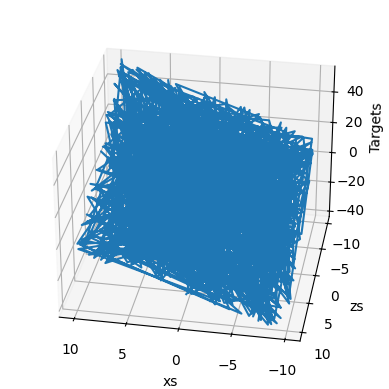

In [18]:
# ============================================================
# BLOK 4 – Wizualizacja danych w 3D
# ============================================================

targets = targets.reshape(observations,)
xs      = xs.reshape(observations,)
zs     = zs.reshape(observations,)

fig = plt.figure()
ax  = fig.add_subplot(111, projection='3d')

ax.plot(xs, zs, targets)
ax.set_xlabel('xs')
ax.set_ylabel('zs')
ax.set_zlabel('Targets')
ax.view_init(azim=100)

plt.show()

In [19]:
# ============================================================
# BLOK 5 – Inicjalizacja wag i biasów
# ============================================================

init_range = 0.1

weights = np.random.uniform(low=-init_range, high=init_range, size=(2, 1))
biases  = np.random.uniform(low=-init_range, high=init_range, size=1)

print(weights, biases)




[[-0.08198191]
 [ 0.01061588]] [-0.01516587]


In [20]:
# ============================================================
# BLOK 6 – Uczenie modelu (gradient descent, 100 epok)
# ============================================================

targets = targets.reshape(observations, 1)
eta = 0.02

for i in range(100):

    outputs = np.dot(inputs, weights) + biases      # y = xw + b
    deltas  = outputs - targets             # różnica: wyjście - cel

    loss = np.sum(deltas ** 2)/2/observations # funkcja straty L2

    print(loss)

    deltas_scaled = deltas / observations
    weights = weights - eta * np.dot(inputs.T, deltas_scaled)  # aktualizacja wag
    biases  = biases  - eta * np.sum(deltas_scaled)             # aktualizacja biasów



225.8416118299695
38.943249108504624
15.165071165839807
11.789826102476587
10.982822716605655
10.512521193066451
10.098967297653807
9.706519566331728
9.33015938900325
8.968727195208997
8.621568076152627
8.288110505773927
7.967812728294943
7.660155272891183
7.364639282769033
7.08078560237183
6.808133987431957
6.5462423570891355
6.294686076889589
6.053057270252575
5.8209641571308115
5.598030418772887
5.383894587555158
5.178209460893494
4.980641538284555
4.790870480563801
4.608588590503451
4.433500313908263
4.265321760400155
4.103780243114717
3.948613836563219
3.7995709519432723
3.656409929209515
3.518898645242909
3.386814137483343
3.2599422424152706
3.138077248320248
3.0210215617332987
2.908585387062354
2.80058641885123
2.6968495461872273
2.5972065687740464
2.5014959242096797
2.409562426027048
2.3212570120726794
2.2364365028154154
2.1549633691932915
2.076705509622135
2.001536035804383
1.92933306699075
1.859979532361226
1.79336298120495
1.7293754005911774
1.6679130402357292
1.608876244278

In [23]:
# ============================================================
# BLOK 7 – Sprawdzenie wyników modelu
# ============================================================
print(weights,biases)


[[ 1.99758053]
 [-3.00209291]] [4.32339707]


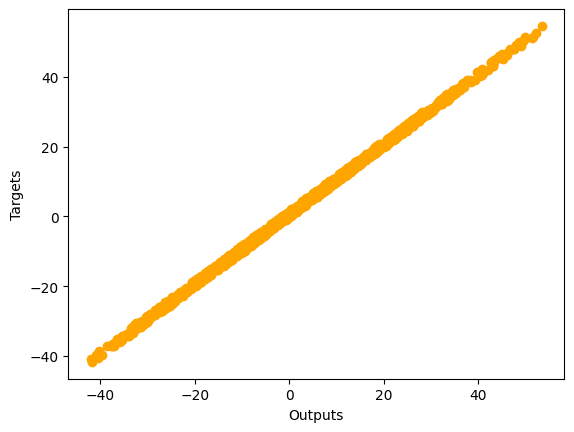

In [24]:
# ============================================================
# BLOK 8 – Porównanie outputs vs targets (dowód liniowości)
# ============================================================

plt.scatter(outputs_final, targets, color='orange')
plt.xlabel('Outputs')
plt.ylabel('Targets')
plt.show()



In [27]:
# 1. Generowanie danych (1 mln próbek)
observations = 1000000
xs = np.random.uniform(low=-10, high=10, size=(observations, 1))
zs = np.random.uniform(low=-10, high=10, size=(observations, 1))
inputs = np.column_stack((xs, zs))

# 2. Tworzenie celów (targets) ze wzoru y = 2x - 3z + 5 + szum
noise = np.random.uniform(low=-1, high=1, size=(observations, 1))
targets = 2 * xs - 3 * zs + 5 + noise

# 3. Inicjalizacja wag i biasów
init_range = 0.1
weights = np.random.uniform(low=-init_range, high=init_range, size=(2, 1))
biases = np.random.uniform(low=-init_range, high=init_range, size=1)

# 4. Pętla ucząca (eta = 0.02)
eta = 0.02
for i in range(100):
    outputs = np.dot(inputs, weights) + biases
    deltas = outputs - targets
    loss = np.sum(deltas ** 2) / 2 / observations
    if i % 10 == 0: print(f"Epoka {i}, Strata: {loss}")

    deltas_scaled = deltas / observations
    weights = weights - eta * np.dot(inputs.T, deltas_scaled)
    biases = biases - eta * np.sum(deltas_scaled)

print("\nWynikowe wagi i bias:")
print(weights, biases)

Epoka 0, Strata: 231.08926949105526
Epoka 10, Strata: 8.792007696770442
Epoka 20, Strata: 5.925025761768247
Epoka 30, Strata: 4.011004356114855
Epoka 40, Strata: 2.7331874364620616
Epoka 50, Strata: 1.8801060261245623
Epoka 60, Strata: 1.3105816431940558
Epoka 70, Strata: 0.9303623360776943
Epoka 80, Strata: 0.6765247027174277
Epoka 90, Strata: 0.5070605463635204

Wynikowe wagi i bias:
[[ 1.99992529]
 [-3.00001906]] [4.32570267]


In [28]:
# Ustawienia dla Ćwiczenia 2
observations = 1000
eta = 0.1  # Tutaj wpisz: 0.0001, 0.001, 0.1 lub 1

# Reszta kodu (uproszczona)
xs = np.random.uniform(-10, 10, (observations, 1))
zs = np.random.uniform(-10, 10, (observations, 1))
inputs = np.column_stack((xs, zs))
targets = 2 * xs - 3 * zs + 5 + np.random.uniform(-1, 1, (observations, 1))

weights = np.random.uniform(-0.1, 0.1, (2, 1))
biases = np.random.uniform(-0.1, 0.1, 1)

for i in range(100):
    outputs = np.dot(inputs, weights) + biases
    deltas = outputs - targets
    loss = np.sum(deltas ** 2) / 2 / observations

    deltas_scaled = deltas / observations
    weights = weights - eta * np.dot(inputs.T, deltas_scaled)
    biases = biases - eta * np.sum(deltas_scaled)

print(f"Dla eta = {eta}, strata końcowa: {loss}")
print(f"Wagi:\n{weights}\nBias: {biases}")

Dla eta = 0.1, strata końcowa: 2.5142089304836708e+78
Wagi:
[[6.70325886e+38]
 [6.57956149e+38]]
Bias: [-5.17843776e+36]


Model powinien zbliżyć się do wag [13, 7] oraz biasu -12:
Wagi:
[[12.99104129]
 [ 6.99790006]]
Bias: [-10.40383811]


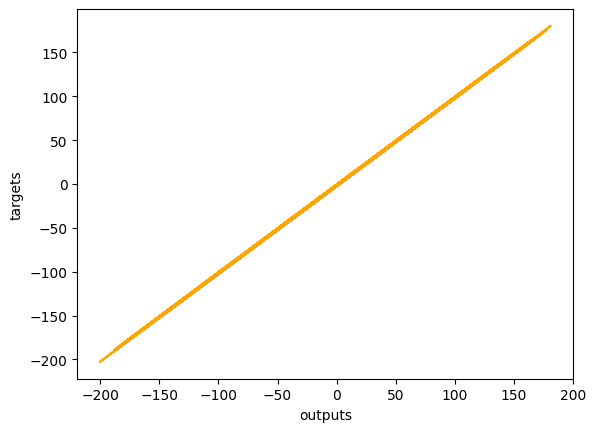

In [30]:
# 1. Nowe parametry celu
observations = 1000
xs = np.random.uniform(-10, 10, (observations, 1))
zs = np.random.uniform(-10, 10, (observations, 1))
inputs = np.column_stack((xs, zs))

# NOWY WZÓR: 13, 7, -12
noise = np.random.uniform(-1, 1, (observations, 1))
targets = 13 * xs + 7 * zs - 12 + noise

# 2. Inicjalizacja
weights = np.random.uniform(-0.1, 0.1, (2, 1))
biases = np.random.uniform(-0.1, 0.1, 1)

# 3. Nauka (eta = 0.02)
eta = 0.02
for i in range(100):
    outputs = np.dot(inputs, weights) + biases
    deltas = outputs - targets
    loss = np.sum(deltas ** 2) / 2 / observations

    deltas_scaled = deltas / observations
    weights = weights - eta * np.dot(inputs.T, deltas_scaled)
    biases = biases - eta * np.sum(deltas_scaled)

print("Model powinien zbliżyć się do wag [13, 7] oraz biasu -12:")
print(f"Wagi:\n{weights}")
print(f"Bias: {biases}")

# 4. Wykres sprawdzający (powinna być linia prosta)
plt.plot(outputs, targets, color='orange')
plt.xlabel('outputs')
plt.ylabel('targets')
plt.show()


Wnioski z eksperymentów

Zadanie 1: Zwiększenie liczby próbek do 1 000 000 pozwoliło modelowi na bardzo precyzyjne odnalezienie wag (blisko 2.0 i -3.0), a systematyczny spadek funkcji straty z poziomu 231 do 0.50 potwierdza, że duży zbiór danych sprzyja stabilnej optymalizacji.
+2

Zadanie 2: Ustawienie zbyt wysokiego eta (0.1) doprowadziło do tzw. eksplozji gradientu, gdzie strata osiągnęła astronomiczny poziom 10^78
 . Dowodzi to, że zbyt duży krok uczenia uniemożliwia znalezienie minimum i powoduje całkowitą destabilizację modelu.
+4
Zadanie 3: Algorytm skutecznie zaadaptował się do nowej funkcji celu (13x+7z−12), poprawnie identyfikując nowe parametry (wagi ~13 i ~7 oraz bias ~ -10.4).


Podsumowując: Sukces uczenia zależy od precyzyjnego balansu między rozmiarem danych a parametrem eta – zbyt agresywne uczenie niszczy model, podczas gdy odpowiednio dobrane parametry pozwalają mu idealnie odtworzyć nawet zmienione zależności matematyczne